In [1]:
import os
import time
import random

import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import models
import albumentations as A
from albumentations.pytorch import ToTensorV2

sns.set(style="whitegrid")
plt.style.use("seaborn-v0_8")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
torch.backends.cudnn.benchmark = True

Using device: cuda


In [2]:
DATA_DIR = "../data/raw"
IMG_DIR  = os.path.join(DATA_DIR, "train_images")

train_csv_path = os.path.join(DATA_DIR, "train.csv")
train_df = pd.read_csv(train_csv_path)

print("Full train_df shape:", train_df.shape)
train_df.head()

Full train_df shape: (3662, 2)


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [3]:
# Stratified train/val split (same as ResNet/EfficientNet)
train_df_split, val_df_split = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["diagnosis"],
    random_state=SEED
)

print("Train split:", train_df_split.shape)
print("Val split:",   val_df_split.shape)
train_df_split["diagnosis"].value_counts(), val_df_split["diagnosis"].value_counts()

Train split: (2929, 2)
Val split: (733, 2)


(diagnosis
 0    1444
 2     799
 1     296
 4     236
 3     154
 Name: count, dtype: int64,
 diagnosis
 0    361
 2    200
 1     74
 4     59
 3     39
 Name: count, dtype: int64)

In [4]:
label_counts = train_df_split["diagnosis"].value_counts().sort_index()
num_classes = len(label_counts)

class_weights = 1.0 / label_counts
class_weights = class_weights / class_weights.sum() * num_classes
class_weights = torch.tensor(class_weights.values, dtype=torch.float32)

print("Label counts:\n", label_counts)
print("Class weights tensor:", class_weights)

Label counts:
 diagnosis
0    1444
1     296
2     799
3     154
4     236
Name: count, dtype: int64
Class weights tensor: tensor([0.2157, 1.0522, 0.3898, 2.0225, 1.3198])


In [5]:
def apply_clahe(img, **kwargs):
    """Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)."""
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    enhanced_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
    return enhanced_img

def circular_crop(img, **kwargs):
    """Apply circular crop to focus on the retina region."""
    height, width, _ = img.shape
    center = (int(width/2), int(height/2))
    radius = min(center[0], center[1], width - center[0], height - center[1])

    Y, X = np.ogrid[:height, :width]
    dist_from_center = np.sqrt((X - center[0])**2 + (Y - center[1])**2)

    mask = dist_from_center <= radius
    cropped = np.zeros_like(img)
    cropped[mask] = img[mask]

    return cropped

In [7]:
IMAGE_SIZE = 320

train_transform = A.Compose([
    A.Lambda(image=apply_clahe),
    A.Lambda(image=circular_crop),

    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    
    # ↓ REPLACE A.Flip WITH THESE ↓
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),

    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.05,
        rotate_limit=15,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.5
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.2, 
        contrast_limit=0.2, 
        p=0.5
    ),
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 5), p=0.5),
        A.MotionBlur(blur_limit=5, p=0.5)
    ], p=0.3),
    
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Lambda(image=apply_clahe),
    A.Lambda(image=circular_crop),
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
])

/home/myid/rm98243/miniconda3/envs/aptos-env/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [8]:
class APTOSDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_id = self.dataframe.loc[idx, "id_code"]
        label = int(self.dataframe.loc[idx, "diagnosis"])
        img_path = os.path.join(self.img_dir, f"{img_id}.png")

        image = np.array(Image.open(img_path).convert("RGB"))

        if self.transform:
            image = self.transform(image=image)["image"]

        return image, torch.tensor(label, dtype=torch.long)

In [ ]:
BATCH_SIZE = 16  

train_dataset = APTOSDataset(train_df_split, IMG_DIR, transform=train_transform)
val_dataset   = APTOSDataset(val_df_split,   IMG_DIR, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 184
Val batches: 46


In [10]:
imgs, labels = next(iter(train_loader))
print("Batch image tensor shape:", imgs.shape)
print("Batch labels shape:", labels.shape)

Batch image tensor shape: torch.Size([16, 3, 320, 320])
Batch labels shape: torch.Size([16])


In [11]:
# Use pretrained DenseNet-121
densenet = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

# Replace classifier
in_features = densenet.classifier.in_features
densenet.classifier = nn.Linear(in_features, 5)

densenet = densenet.to(device)

# Multi-GPU if available
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs for DenseNet-121!")
    densenet = nn.DataParallel(densenet)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /home/myid/rm98243/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 74.3MB/s]

Using 2 GPUs for DenseNet-121!


In [12]:
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

optimizer = optim.AdamW(
    densenet.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

/tmp/ipykernel_3137983/371277484.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


In [ ]:
NUM_EPOCHS = 15
best_val_acc = 0.0
history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": []
}

save_path = "../models/best_densenet121_320.pth"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    print("-" * 30)

    # Train
    densenet.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    pbar = tqdm(train_loader, desc=f"Train Epoch {epoch}", leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = densenet(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    epoch_train_loss = train_loss / train_total
    epoch_train_acc  = train_correct / train_total


    # Validation

    densenet.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        pbar = tqdm(val_loader, desc=f"Val Epoch {epoch}", leave=False)
        for images, labels in pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                outputs = densenet(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = val_loss / val_total
    epoch_val_acc  = val_correct / val_total

    history["train_loss"].append(epoch_train_loss)
    history["val_loss"].append(epoch_val_loss)
    history["val_acc"].append(epoch_val_acc)

    # Step LR
    scheduler.step()

    print(
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.4f}"
    )

    # Save best model
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(densenet.state_dict(), save_path)
        print(f"🔥 Saved Best DenseNet-121 model at epoch {epoch} (Val Acc: {best_val_acc:.4f})")


Epoch 1/15
------------------------------


Train Epoch 1:   0%|          | 0/184 [00:00<?, ?it/s]/tmp/ipykernel_3137983/1426004304.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
Val Epoch 1:   0%|          | 0/46 [00:00<?, ?it/s]                          /tmp/ipykernel_3137983/1426004304.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Train Loss: 1.1839 | Train Acc: 0.5865 | Val Loss: 1.0290 | Val Acc: 0.6903
🔥 Saved Best DenseNet-121 model at epoch 1 (Val Acc: 0.6903)

Epoch 2/15
------------------------------


Train Loss: 0.9891 | Train Acc: 0.7043 | Val Loss: 1.0020 | Val Acc: 0.7531
🔥 Saved Best DenseNet-121 model at epoch 2 (Val Acc: 0.7531)

Epoch 3/15
------------------------------


Train Loss: 0.9272 | Train Acc: 0.7238 | Val Loss: 0.9236 | Val Acc: 0.7558
🔥 Saved Best DenseNet-121 model at epoch 3 (Val Acc: 0.7558)

Epoch 4/15
------------------------------


...

Train Loss: 0.5746 | Train Acc: 0.8395 | Val Loss: 0.8146 | Val Acc: 0.8008
🔥 Saved Best DenseNet-121 model at epoch 11 (Val Acc: 0.8008)

Epoch 12/15
------------------------------


Train Loss: 0.5200 | Train Acc: 0.8576 | Val Loss: 0.8434 | Val Acc: 0.8008

Epoch 13/15
------------------------------


Train Loss: 0.5200 | Train Acc: 0.8580 | Val Loss: 0.8718 | Val Acc: 0.8049
🔥 Saved Best DenseNet-121 model at epoch 13 (Val Acc: 0.8049)

Epoch 14/15
------------------------------


Train Loss: 0.4732 | Train Acc: 0.8764 | Val Loss: 0.8940 | Val Acc: 0.8158
🔥 Saved Best DenseNet-121 model at epoch 14 (Val Acc: 0.8158)

Epoch 15/15
------------------------------


Train Loss: 0.4662 | Train Acc: 0.8716 | Val Loss: 0.8704 | Val Acc: 0.7995


## Plot Training Curves

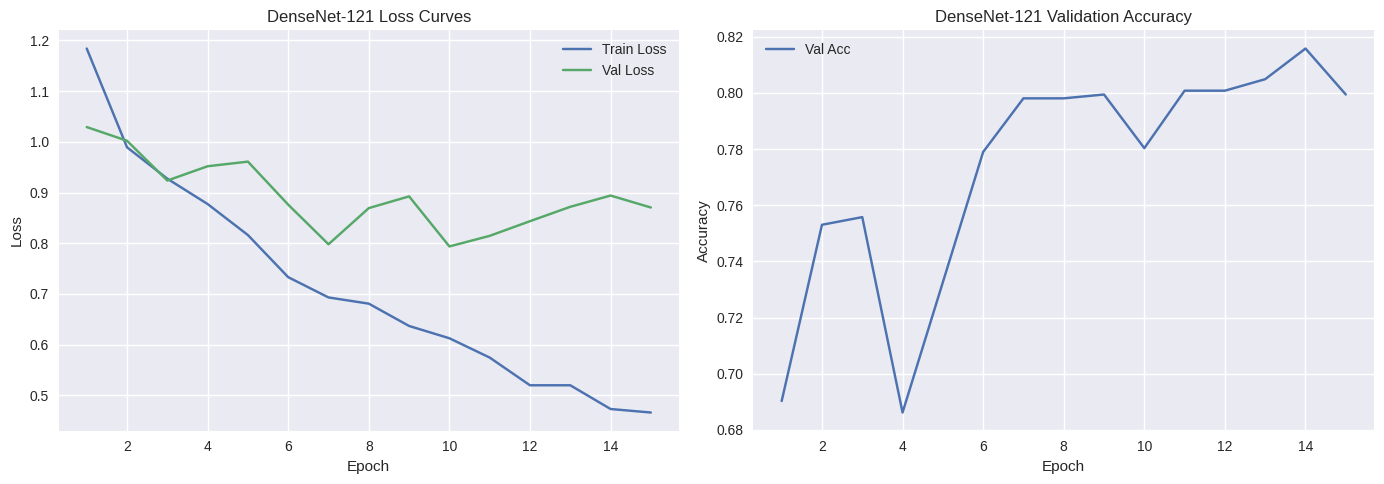

Best Validation Accuracy: 0.8158


In [14]:
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet-121 Loss Curves")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DenseNet-121 Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Best Validation Accuracy: {best_val_acc:.4f}")

## Final Evaluation on Validation Set

Final Inference (Val): 100%|██████████| 46/46 [01:14<00:00,  1.62s/it]



Classification Report (DenseNet-121 320×320):

              precision    recall  f1-score   support

           0     0.9749    0.9695    0.9722       361
           1     0.5106    0.6486    0.5714        74
           2     0.7947    0.7550    0.7744       200
           3     0.4444    0.4103    0.4267        39
           4     0.6111    0.5593    0.5841        59

    accuracy                         0.8158       733
   macro avg     0.6672    0.6686    0.6657       733
weighted avg     0.8214    0.8158    0.8175       733



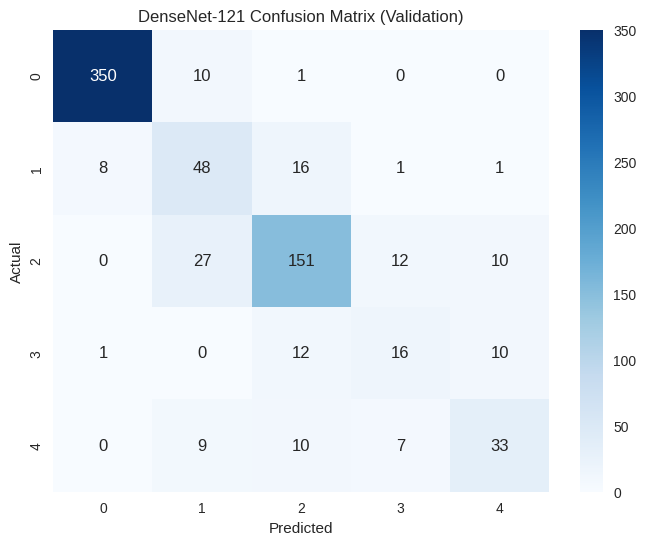

In [15]:
# Reload best model
best_model = models.densenet121(weights=None)
best_model.classifier = nn.Linear(best_model.classifier.in_features, 5)

if torch.cuda.device_count() > 1:
    best_model = nn.DataParallel(best_model)

best_model.load_state_dict(torch.load(save_path, map_location=device))
best_model = best_model.to(device)
best_model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Final Inference (Val)"):
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_model(images)
        preds = outputs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\nClassification Report (DenseNet-121 320×320):\n")
print(classification_report(y_true, y_pred, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[0,1,2,3,4],
    yticklabels=[0,1,2,3,4]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DenseNet-121 Confusion Matrix (Validation)")
plt.show()